---
title: "Data Cleaning"
format:
    html: 
        code-fold: false
---

# Introduction and Motivation
Data cleaning is the essential first step in any data science project. It acts as the bridge between raw, messy files and reliable results. For our project, we are combining two very different data sources: **Grid Power Data** and **Weather Observations**.

On this page, our goal is to turn the raw, separate files we collected into a single, high-quality dataset. Specifically, we aim to:

1. **Check Data Quality:** Look at how much data is missing, especially comparing reliable wind data against spotty temperature data.
2. **Fix Formatting Errors:** Solve structure problems, such as the messy headers we found in the BPA Excel files, so the computer reads them correctly.
3. **Correct Impossible Values:** Find and fix logical errors, such as negative power generation numbers, which shouldn't exist in reality.
4. **Standardize the Numbers:** Adjust the scale of our data so that features with different units (like Megawatts vs. Knots) work well together in our clustering models.

By the end of this section, we will produce clean, reliable dataset (`BPA_Cleaned_Final_Robust.csv`) that we can trust for the rest of the project.

# Overview of the Methods

### 1. Subsetting and Reshaping 
Before cleaning individual values, we had to fix the overall shape of the data.
* **The Problem:** The weather data is in a **"Long Format"** , making it impossible to use as separate features for a model.
* **The Reshaping:** We used a **Pivot Table** transformation to convert the weather data into a **"Wide Format"**. 

### 2. Managing Missing Data
Once the structure was fixed, we handled the empty cells.
* **Dropping Columns:** For variables like Temperature (`tmpf`) and Pressure (`mslp`) that were missing >90% of data, we removed the entire column to avoid noise.
* **Filling Gaps:** For critical Wind Speed and Power data (missing <5%), we used **Linear Time Interpolation**. This fills gaps by drawing a straight line between the known points before and after.

### 3. Data Type Correction
We converted the `Power_MW` column from "Object" (Text) to **Float (Number)** and ensured the `Timestamp` was a proper **Date-Time object**. This allows us to sort chronologically and calculate time-based features later.

### 4. Outlier Detection and Treatment
We checked for values that violated physical laws.
* **Finding Errors:** We identified **negative numbers** in the Power Generation column. Wind farms cannot consume power from the grid in this context.
* **Fixing It:** We **clipped** these negative values to 0. We deliberately kept extreme high values because those represent the "Ramp Events" we want to predict.

### 5. Normalization and Scaling
Machine learning models struggle when numbers have different sizes (e.g., MW vs. Knots).
* **Technique:** We used **Min-Max Scaling** to create a new column `Power_MW_Scaled`, squeezing the values between **0 and 1**.



# Code 

The following Python script implements the complete cleaning workflow. It loads the raw data, executes type conversion and filtering, calculates the resolution time for outlier detection, and applies normalization scaling.

In [ ]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

### Merge Wind Gen Total files

In [119]:

# ================= Configuration =================
DATA_DIR = "../../data/raw-data"
OUTPUT_FILE = "../../data/processed-data/BPA_Merged_Raw_2022_2025.csv"

def merge_standard_years():
    all_dfs = []
    years = [2022, 2023, 2024, 2025]

    for year in years:
        filename = f"WindGenTotalLoadYTD_{year}.xlsx"
        file_path = os.path.join(DATA_DIR, filename)

        if os.path.exists(file_path):
            try:
                # header=1: skip the first descriptive row and use the second row as column names
                df = pd.read_excel(file_path, header=1, engine="openpyxl")
                all_dfs.append(df)
            except Exception:
                continue

    if all_dfs:
        full_df = pd.concat(all_dfs, ignore_index=True)

        # Convert datetime column and remove invalid rows
        full_df["timestamp"] = pd.to_datetime(
            full_df["Date/Time"], errors="coerce"
        )
        full_df = full_df.dropna(subset=["timestamp"])
        full_df = full_df.sort_values("timestamp")

        # Ensure output directory exists
        os.makedirs(os.path.dirname(OUTPUT_FILE), exist_ok=True)
        full_df.to_csv(OUTPUT_FILE, index=False)

merge_standard_years()


/var/folders/6f/mpj7nyk15wx2xll23dsk4zk80000gn/T/ipykernel_64601/376263138.py:28: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  full_df["timestamp"] = pd.to_datetime(


### Merge Wind Gen files and Weather files

In [110]:
# 1. Load data
df_weather = pd.read_csv("../../data/raw-data/BPA_Weather_IEM_Parallel.csv")
df_wind = pd.read_csv("../../data/processed-data/BPA_Merged_Raw_2022_2025.csv")

# 2. Standardize timestamp format
df_weather["timestamp"] = pd.to_datetime(df_weather["valid"])
df_wind["timestamp"] = pd.to_datetime(df_wind["timestamp"])

# 3. Pivot weather data (Long -> Wide)
features = ["tmpf", "dwpf", "drct", "sknt", "mslp"]

weather_wide = df_weather.pivot_table(
    index="timestamp",
    columns="station",
    values=features
)

# Flatten multi-level columns
weather_wide.columns = [f"{col[1]}_{col[0]}" for col in weather_wide.columns]
weather_wide = weather_wide.reset_index()

# 4. Merge with wind generation data
df_final = pd.merge(
    df_wind[["timestamp", "TOTAL WIND GENERATION  IN BPA CONTROL AREA (MW; SCADA 79687)"]],
    weather_wide,
    on="timestamp",
    how="inner"
)

# Rename target column
df_final = df_final.rename(
    columns={
        "TOTAL WIND GENERATION  IN BPA CONTROL AREA (MW; SCADA 79687)": "Target_Power_MW"
    }
)

print("Merge completed successfully.")


Merge completed successfully.


### Cleaning

Original data shape: (388665, 22)

--- Step 1: Type correction and renaming ---

--- Step 2: Missing data handling (drop & interpolate) ---
Columns with highest missing ratios:
 SEA_mslp    1.000000
GEG_mslp    0.999995
PDX_mslp    0.999995
EUG_mslp    0.999982
GEG_tmpf    0.996344
dtype: float64


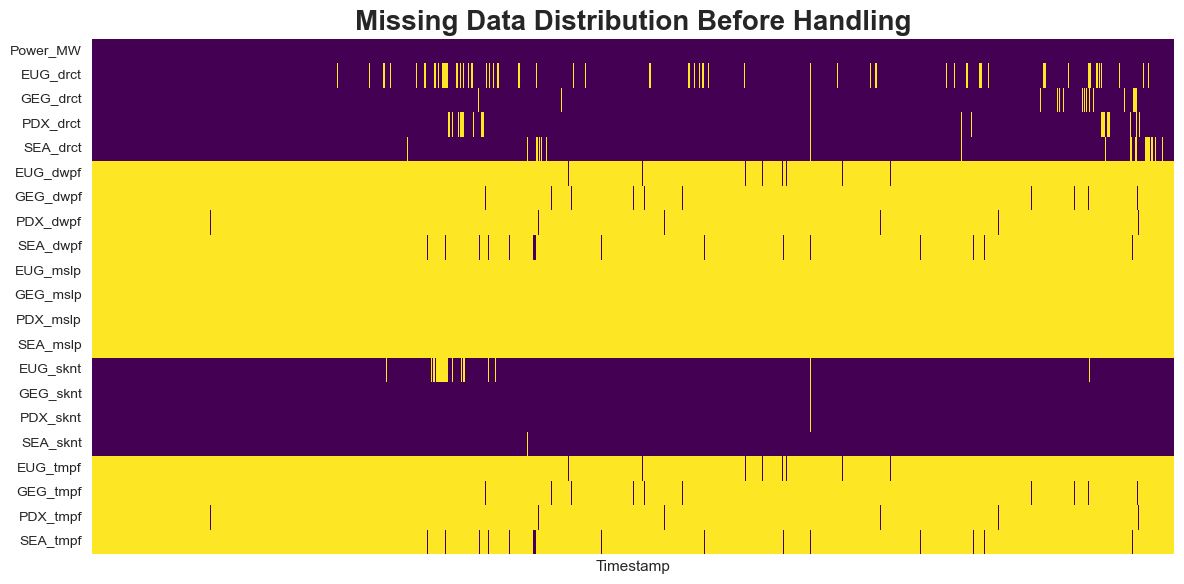


Dropping 12 columns with >40% missing values:
['EUG_dwpf', 'GEG_dwpf', 'PDX_dwpf', 'SEA_dwpf', 'EUG_mslp', 'GEG_mslp', 'PDX_mslp', 'SEA_mslp', 'EUG_tmpf', 'GEG_tmpf', 'PDX_tmpf', 'SEA_tmpf']

Applying time-based linear interpolation...
Remaining missing values after processing: 0


/var/folders/6f/mpj7nyk15wx2xll23dsk4zk80000gn/T/ipykernel_64601/3094269243.py:54: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_clean = df_clean.fillna(method="bfill").fillna(method="ffill")


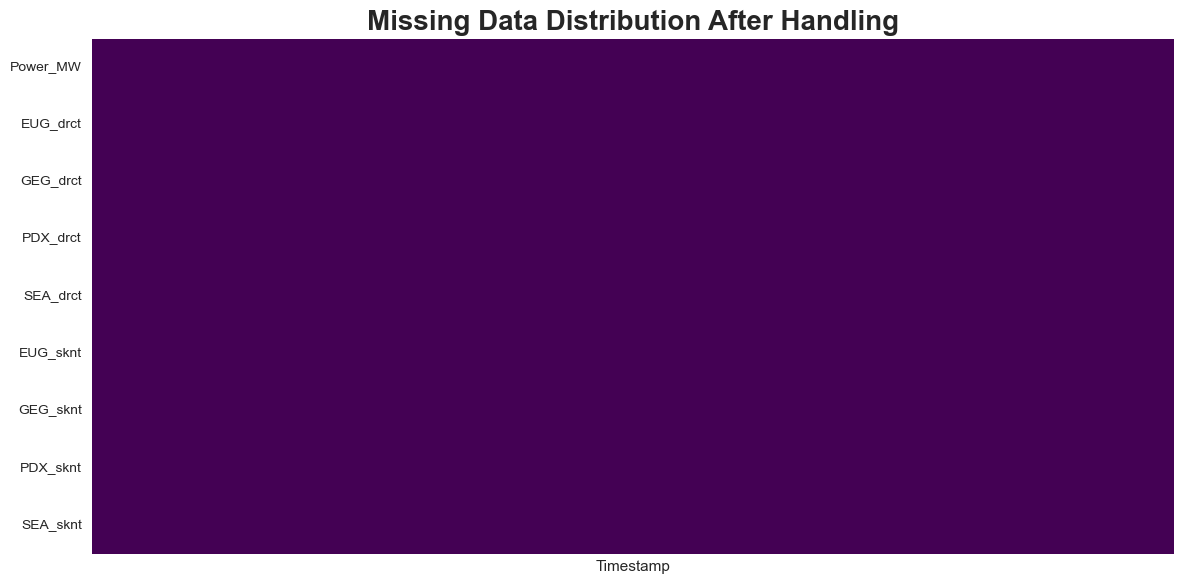


--- Step 3: Outlier handling ---


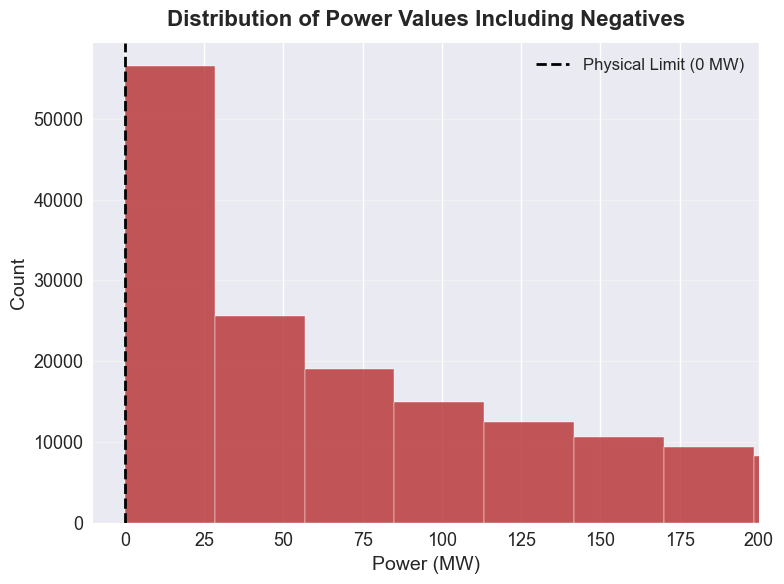

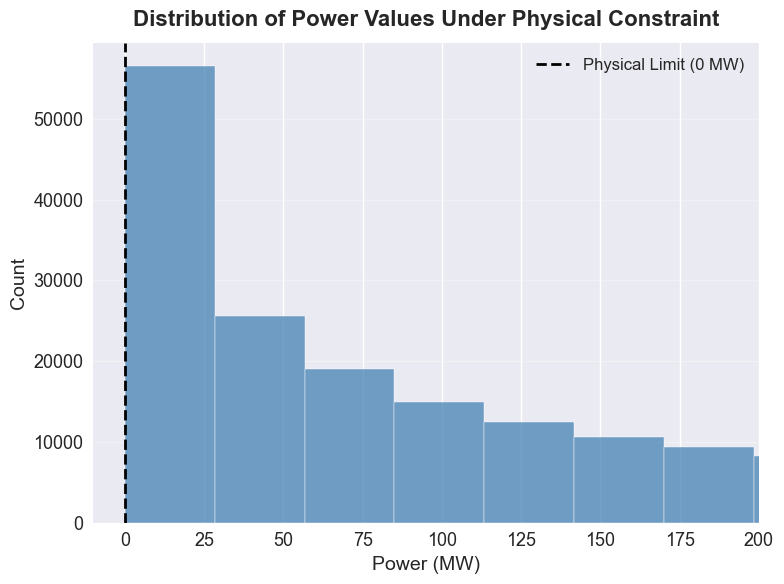


--- Step 4: Normalization ---


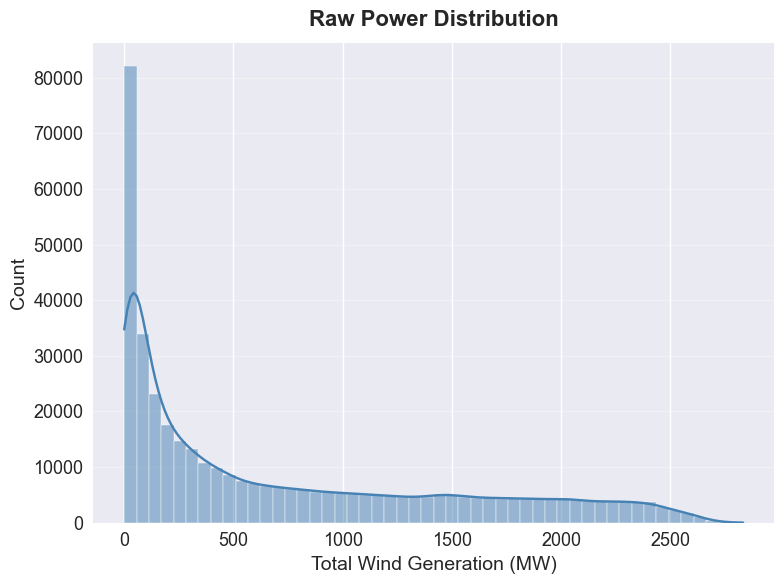

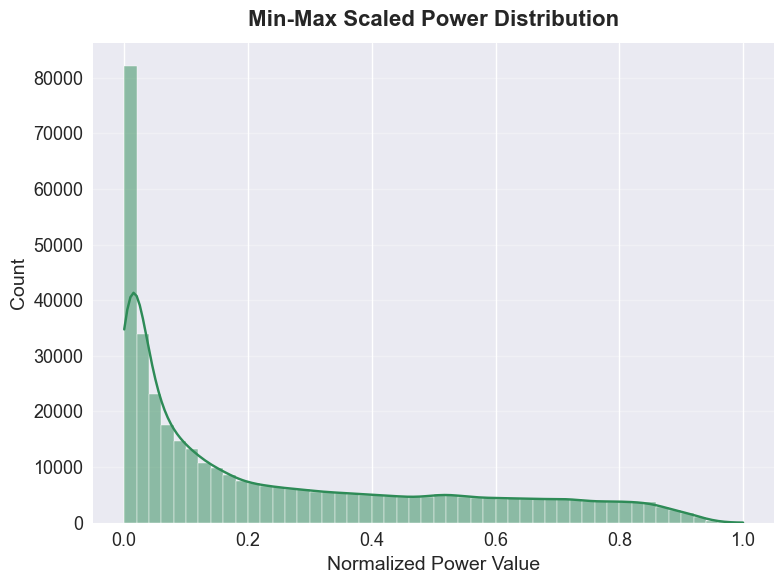


Data cleaning completed.


In [122]:
# Plot style
plt.style.use("seaborn-v0_8")
sns.set_palette("husl")

df = df_final
print(f"Original data shape: {df.shape}")


print("\n--- Step 1: Type correction and renaming ---")

df = df.rename(columns={
    "timestamp": "Timestamp",
    "Target_Power_MW": "Power_MW"
})

df["Timestamp"] = pd.to_datetime(df["Timestamp"])
df["Power_MW"] = pd.to_numeric(df["Power_MW"], errors="coerce")

df_clean = df.set_index("Timestamp").sort_index()

print("\n--- Step 2: Missing data handling (drop & interpolate) ---")

missing_ratio = df_clean.isnull().mean()
print(
    "Columns with highest missing ratios:\n",
    missing_ratio[missing_ratio > 0].sort_values(ascending=False).head(5)
)

# Missing data heatmap (before)
plt.figure(figsize=(12, 6))
sns.heatmap(
    df_clean.head(2000).isnull().transpose(),
    cbar=False,
    cmap="viridis",
    xticklabels=False
)
plt.title("Missing Data Distribution Before Handling", fontsize=20, fontweight='bold')
plt.tight_layout()
plt.show()

threshold = 0.9
cols_to_drop = missing_ratio[missing_ratio > threshold].index.tolist()

if cols_to_drop:
    print(f"\nDropping {len(cols_to_drop)} columns with >40% missing values:")
    print(cols_to_drop)
    df_clean = df_clean.drop(columns=cols_to_drop)
else:
    print("\nNo columns dropped.")

print("\nApplying time-based linear interpolation...")
df_clean = df_clean.interpolate(method="time")

df_clean = df_clean.fillna(method="bfill").fillna(method="ffill")

print(f"Remaining missing values after processing: {df_clean.isnull().sum().sum()}")

# Missing data heatmap (after)
plt.figure(figsize=(12, 6))
sns.heatmap(
    df_clean.head(2000).isnull().transpose(),
    cbar=False,
    cmap="viridis",
    xticklabels=False
)
plt.title("Missing Data Distribution After Handling", fontsize=20, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n--- Step 3: Outlier handling ---")

TICK_SIZE = 13
LABEL_SIZE = 14
TITLE_SIZE = 16

plt.figure(figsize=(8, 6))

# Plot Histogram
sns.histplot(df_clean['Power_MW'], bins=100, color='firebrick', kde=False)

# Zoom in on the lower range
plt.xlim(df_clean['Power_MW'].min() - 10, 200)

# Physical limit line
plt.axvline(
    0,
    color='black',
    linestyle='--',
    linewidth=2,
    label='Physical Limit (0 MW)'
)

# Titles and labels
plt.title(
    'Distribution of Power Values Including Negatives',
    fontsize=TITLE_SIZE,
    fontweight='bold',
    pad=12
)
plt.xlabel('Power (MW)', fontsize=LABEL_SIZE)
plt.ylabel('Count', fontsize=LABEL_SIZE)

# Tick size
plt.xticks(fontsize=TICK_SIZE)
plt.yticks(fontsize=TICK_SIZE)

# Legend
plt.legend(fontsize=12)

# Grid (subtle)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


# ---------- Data cleaning ----------
negative_count = (df_clean["Power_MW"] < 0).sum()
if negative_count > 0:
    print(f"Detected {negative_count} negative power values; clipped to zero.")
    df_clean["Power_MW"] = df_clean["Power_MW"].clip(lower=0)


# ---------- After constraint ----------
plt.figure(figsize=(8, 6))

sns.histplot(df_clean['Power_MW'], bins=100, color='steelblue', kde=False)

# Keep same zoom for comparison
plt.xlim(df_clean['Power_MW'].min() - 10, 200)

plt.axvline(
    0,
    color='black',
    linestyle='--',
    linewidth=2,
    label='Physical Limit (0 MW)'
)

plt.title(
    'Distribution of Power Values Under Physical Constraint',
    fontsize=TITLE_SIZE,
    fontweight='bold',
    pad=12
)
plt.xlabel('Power (MW)', fontsize=LABEL_SIZE)
plt.ylabel('Count', fontsize=LABEL_SIZE)

plt.xticks(fontsize=TICK_SIZE)
plt.yticks(fontsize=TICK_SIZE)

plt.legend(fontsize=12)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()



print("\n--- Step 4: Normalization ---")
plt.figure(figsize=(8, 6))

sns.histplot(
    df_clean['Power_MW'],
    bins=50,
    kde=True,
    color='steelblue'
)

plt.title(
    'Raw Power Distribution',
    fontsize=TITLE_SIZE,
    fontweight='bold',
    pad=12
)
plt.xlabel('Total Wind Generation (MW)', fontsize=LABEL_SIZE)
plt.ylabel('Count', fontsize=LABEL_SIZE)

plt.xticks(fontsize=TICK_SIZE)
plt.yticks(fontsize=TICK_SIZE)

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


# ---------- Min-Max normalization ----------
scaler = MinMaxScaler()
df_clean["Power_MW_Scaled"] = scaler.fit_transform(df_clean[["Power_MW"]])

plt.figure(figsize=(8, 6))

sns.histplot(
    df_clean['Power_MW_Scaled'],
    bins=50,
    kde=True,
    color='seagreen'
)

plt.title(
    'Min-Max Scaled Power Distribution',
    fontsize=TITLE_SIZE,
    fontweight='bold',
    pad=12
)
plt.xlabel('Normalized Power Value', fontsize=LABEL_SIZE)
plt.ylabel('Count', fontsize=LABEL_SIZE)

plt.xticks(fontsize=TICK_SIZE)
plt.yticks(fontsize=TICK_SIZE)

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


output_file = "../../data/processed-data/BPA_Cleaned_Final_Robust.csv"
df_clean.to_csv(output_file)

print("\nData cleaning completed.")


# Summary and Interpretation of Results
### **Feature selection & Reshaping**
From the raw disparate sources, we merged and pivoted to a **station–time wide table** with:

* **Grid Series** – e.g. **Power_MW** (Actual Wind Generation), **Timestamp** (UTC).
* **Weather Series** – e.g. **sknt** (Wind Speed), **drct** (Wind Direction) for stations PDX, GEG, SEA, EUG.
* **Saved as:** `BPA_Dataset_Final_Merged.csv`.

### **Missingness check & cleaning**
Computed **missing per column** and visualized it as a **heatmap**.

* **Weather Data** – Dropped very sparse series (>90% missing): **tmpf** (Temperature), **mslp** (Pressure), **dwpf** (Dew Point).
* **Wind Gen Data** – Imputed small gaps (<5% missing) in **sknt**, **drct**, and **Power_MW** using **Linear Time Interpolation**.

### **Outlier handling & formatting**

* **Physical Constraints** – Detected negative values in **Power_MW**; **clipped to 0** to enforce physical validity (Energy \ge 0).
* **Type Correction** – Converted **Timestamp** to datetime objects and **Power_MW** from object to float64.

### **Normalization**

* Created **Power_MW_Scaled** using **Min-Max Scaling** to map values to [0, 1].
* **Output:** `BPA_Cleaned_Final_Robust.csv`
  with **105,120 rows × 10 columns**, used for later modeling and analysis.